/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Se creó el archivo de ejemplo: serie_temporal.csv

RESULTADOS DEL MODELO
Error absoluto medio: 1.97
Raíz del error cuadrático medio: 2.25
R²: 0.9133

ÚLTIMAS PREDICCIONES
     fecha  valor_real  valor_predicho
2024-06-19  133.470250      134.033721
2024-06-20  128.357217      129.812650
2024-06-21  121.306959      122.558772
2024-06-22  116.883025      118.407196
2024-06-23  118.835067      120.478030
2024-06-24  127.904366      125.929122
2024-06-25  134.244319      133.052863
2024-06-26  139.206347      134.765249
2024-06-27  130.509524      130.698830
2024-06-28  127.951501      122.621980

PREDICCIÓN DEL SIGUIENTE VALOR
Fecha: 2024-06-29
Valor estimado: 119.28

¿Cuántos valores futuros deseas predecir? (0 para omitir): 3


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(



PREDICCIONES FUTURAS
     fecha  valor_predicho
2024-06-29      119.282178
2024-06-30      120.750656
2024-07-01      129.059895

Modelo guardado como: modelo_series_temporales.pkl


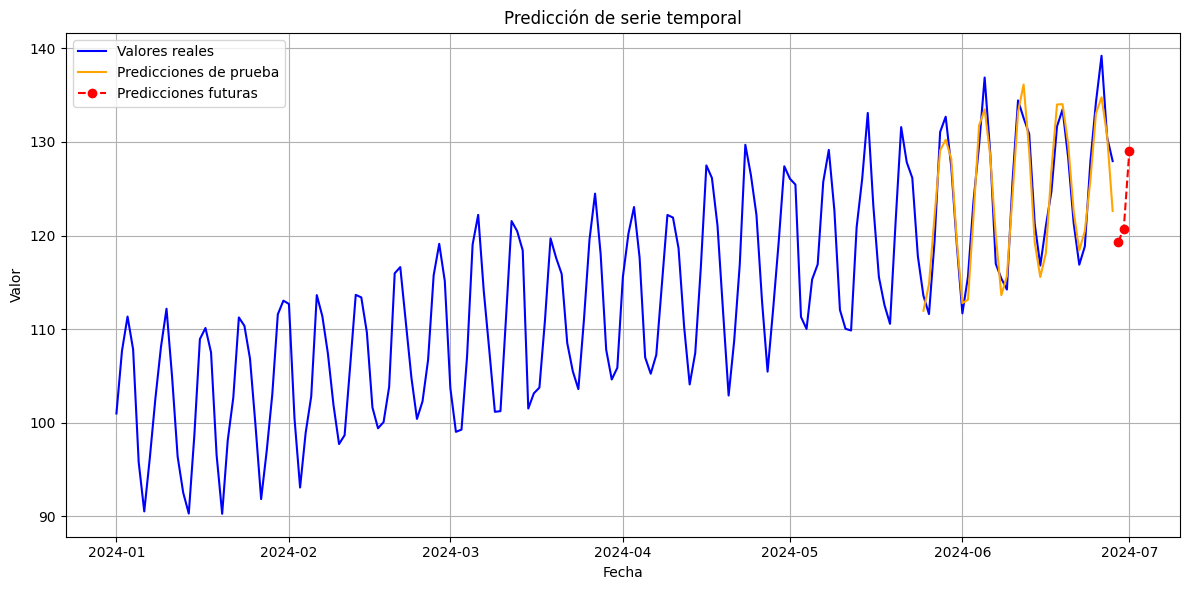

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ==========================================
# 1. Configuración
# ==========================================

ARCHIVO_DATOS = "serie_temporal.csv"
ARCHIVO_MODELO = "modelo_series_temporales.pkl"

COLUMNA_FECHA = "fecha"
COLUMNA_VALOR = "valor"

NUMERO_REZAGOS = 7


# ==========================================
# 2. Crear datos de ejemplo si no existe CSV
# ==========================================

if not os.path.exists(ARCHIVO_DATOS):
    np.random.seed(42)

    fechas = pd.date_range(
        start="2024-01-01",
        periods=180,
        freq="D"
    )

    valores = []

    for dia in range(len(fechas)):
        tendencia = dia * 0.15
        estacionalidad = 10 * np.sin(dia * 2 * np.pi / 7)
        ruido = np.random.normal(0, 2)

        valor = 100 + tendencia + estacionalidad + ruido
        valores.append(valor)

    datos_ejemplo = pd.DataFrame({
        "fecha": fechas,
        "valor": valores
    })

    datos_ejemplo.to_csv(
        ARCHIVO_DATOS,
        index=False,
        encoding="utf-8"
    )

    print(f"Se creó el archivo de ejemplo: {ARCHIVO_DATOS}")


# ==========================================
# 3. Cargar y ordenar los datos
# ==========================================

try:
    datos = pd.read_csv(ARCHIVO_DATOS)
except FileNotFoundError:
    print(f"No se encontró el archivo '{ARCHIVO_DATOS}'.")
    exit()

columnas_requeridas = [COLUMNA_FECHA, COLUMNA_VALOR]

if not all(columna in datos.columns for columna in columnas_requeridas):
    print("El archivo CSV debe contener estas columnas:")
    print("fecha, valor")
    exit()

datos[COLUMNA_FECHA] = pd.to_datetime(datos[COLUMNA_FECHA])

datos[COLUMNA_VALOR] = pd.to_numeric(
    datos[COLUMNA_VALOR],
    errors="coerce"
)

datos = datos.dropna(
    subset=[COLUMNA_FECHA, COLUMNA_VALOR]
)

datos = datos.sort_values(COLUMNA_FECHA)
datos = datos.drop_duplicates(
    subset=[COLUMNA_FECHA]
)
datos = datos.reset_index(drop=True)


if len(datos) <= NUMERO_REZAGOS + 10:
    print("Necesitas más datos para entrenar el modelo.")
    exit()


# ==========================================
# 4. Crear variables de rezago
# ==========================================

for i in range(1, NUMERO_REZAGOS + 1):
    datos[f"rezago_{i}"] = datos[COLUMNA_VALOR].shift(i)

datos_modelo = datos.dropna().reset_index(drop=True)

columnas_rezagos = [
    f"rezago_{i}"
    for i in range(1, NUMERO_REZAGOS + 1)
]

X = datos_modelo[columnas_rezagos]
y = datos_modelo[COLUMNA_VALOR]


# ==========================================
# 5. Separar entrenamiento y prueba
# ==========================================

# El 80 % inicial se usa para entrenar.
# El 20 % final se usa para probar el modelo.

cantidad_entrenamiento = int(len(datos_modelo) * 0.80)

X_entrenamiento = X.iloc[:cantidad_entrenamiento]
X_prueba = X.iloc[cantidad_entrenamiento:]

y_entrenamiento = y.iloc[:cantidad_entrenamiento]
y_prueba = y.iloc[cantidad_entrenamiento:]


# ==========================================
# 6. Entrenar el modelo
# ==========================================

modelo = LinearRegression()

modelo.fit(
    X_entrenamiento,
    y_entrenamiento
)


# ==========================================
# 7. Evaluar el modelo
# ==========================================

predicciones = modelo.predict(X_prueba)

mae = mean_absolute_error(
    y_prueba,
    predicciones
)

rmse = mean_squared_error(
    y_prueba,
    predicciones
) ** 0.5

r2 = r2_score(
    y_prueba,
    predicciones
)

print("\nRESULTADOS DEL MODELO")
print("=====================")
print(f"Error absoluto medio: {mae:.2f}")
print(f"Raíz del error cuadrático medio: {rmse:.2f}")
print(f"R²: {r2:.4f}")


# ==========================================
# 8. Mostrar predicciones de prueba
# ==========================================

resultados = pd.DataFrame({
    "fecha": datos_modelo.loc[
        cantidad_entrenamiento:,
        COLUMNA_FECHA
    ].values,
    "valor_real": y_prueba.values,
    "valor_predicho": predicciones
})

print("\nÚLTIMAS PREDICCIONES")
print("====================")
print(resultados.tail(10).to_string(index=False))

resultados.to_csv(
    "resultados_series_temporales.csv",
    index=False,
    encoding="utf-8"
)


# ==========================================
# 9. Predecir el siguiente valor
# ==========================================

ultimos_valores = datos[COLUMNA_VALOR].tail(
    NUMERO_REZAGOS
).values

entrada_siguiente = np.array([
    ultimos_valores[::-1]
])

siguiente_prediccion = modelo.predict(
    entrada_siguiente
)[0]

ultima_fecha = datos[COLUMNA_FECHA].iloc[-1]

diferencia_fechas = datos[COLUMNA_FECHA].diff().dropna()

if len(diferencia_fechas) > 0:
    frecuencia = diferencia_fechas.mode().iloc[0]
else:
    frecuencia = pd.Timedelta(days=1)

siguiente_fecha = ultima_fecha + frecuencia

print("\nPREDICCIÓN DEL SIGUIENTE VALOR")
print("==============================")
print(f"Fecha: {siguiente_fecha.strftime('%Y-%m-%d')}")
print(f"Valor estimado: {siguiente_prediccion:.2f}")


# ==========================================
# 10. Predecir varios valores futuros
# ==========================================

try:
    cantidad_futura = int(
        input(
            "\n¿Cuántos valores futuros deseas predecir? "
            "(0 para omitir): "
        )
    )
except ValueError:
    cantidad_futura = 0

if cantidad_futura > 0:
    historial = list(
        datos[COLUMNA_VALOR].values
    )

    fechas_futuras = []
    valores_futuros = []

    for paso in range(1, cantidad_futura + 1):
        ultimos = historial[-NUMERO_REZAGOS:]

        entrada = np.array([
            ultimos[::-1]
        ])

        prediccion_futura = modelo.predict(
            entrada
        )[0]

        fecha_futura = ultima_fecha + (
            frecuencia * paso
        )

        fechas_futuras.append(fecha_futura)
        valores_futuros.append(prediccion_futura)

        # Se añade la predicción para usarla
        # en el cálculo del siguiente paso.
        historial.append(prediccion_futura)

    futuro = pd.DataFrame({
        "fecha": fechas_futuras,
        "valor_predicho": valores_futuros
    })

    print("\nPREDICCIONES FUTURAS")
    print("====================")
    print(futuro.to_string(index=False))

    futuro.to_csv(
        "predicciones_futuras.csv",
        index=False,
        encoding="utf-8"
    )


# ==========================================
# 11. Guardar el modelo
# ==========================================

joblib.dump(
    modelo,
    ARCHIVO_MODELO
)

print(f"\nModelo guardado como: {ARCHIVO_MODELO}")


# ==========================================
# 12. Mostrar gráfico
# ==========================================

plt.figure(figsize=(12, 6))

plt.plot(
    datos[COLUMNA_FECHA],
    datos[COLUMNA_VALOR],
    label="Valores reales",
    color="blue"
)

plt.plot(
    resultados["fecha"],
    resultados["valor_predicho"],
    label="Predicciones de prueba",
    color="orange"
)

if cantidad_futura > 0:
    plt.plot(
        futuro["fecha"],
        futuro["valor_predicho"],
        label="Predicciones futuras",
        color="red",
        linestyle="--",
        marker="o"
    )

plt.title("Predicción de serie temporal")
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()